#### Fig. 6b

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc  
#import squidpy as sq
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import torch 
import os

pd.set_option('display.max_columns',500)
pd.set_option('display.max_categories',60)
pd.set_option('display.max_rows', 500)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'axes.facecolor': 'white',
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title
})

In [4]:
save_dir = "figs"
os.makedirs(save_dir, exist_ok=True)

In [5]:
adata_vis = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/nmf/ann_finest_level/nfact12/h5ad/adata_vis_assigned_cell_types_nfact12_assigned_factors_log_minmax.h5ad")


In [6]:
# Create new column "lay_id" from "cond_rep", replacing _ with # to look better
adata_vis.obs['lay_id'] = adata_vis.obs['cond_rep'].astype(str).str.replace("_"," #")

In [7]:
# So that we can dynamically switch library_id (key) with lay_id (value)
key_map = dict(zip(adata_vis.obs['library_id'].drop_duplicates(), adata_vis.obs['lay_id'].drop_duplicates()))
key_map

{'18_57617_A1': 'IPF #1',
 '20_33940_B2': 'IPF #2',
 '20_24241_A2': 'IPF #3',
 '19_35057_C3': 'NSIP #1',
 '20_17688_B2': 'NSIP #2',
 '20_28197_A1': 'IPF #4',
 '20_22642_A1': 'NSIP #3',
 '20_41501_C1': 'IPF #5',
 '20_33362_C4': 'NSIP #4',
 '20_41847_A1': 'UNC #1',
 '20_41615_B1': 'IPF #6',
 '21_06301_B2': 'IPF #7',
 '21_05738_A1': 'UNC #2',
 '21_57231_A3': 'CHP #1',
 '21_25528_A3': 'UNC #3',
 '22_18446_A1': 'UNC #4',
 '22_18440_A2': 'CHP #2',
 '23_15209_A3': 'CHP #3',
 '22_50637_A1': 'UNC #5',
 '23_50343_B2': 'CHP #4',
 '23_41922_B2': 'CHP #5',
 '24_10794_B1': 'UNC #7',
 '20_12743_C1': 'UNC #8',
 '21_55244_B1': 'UNC #9',
 '23_45450_A3': 'UNC #10',
 '24_23755_A1': 'UNC #11',
 '16_53837_A10': 'UNC #12',
 '19_48719_A1': 'UNC #13',
 '17_35291_B1': 'UNC #14',
 '16_46257_A1': 'UNC #15',
 '18_23779_A2': 'UNC #16',
 '12_39986_A2': 'UNC #17',
 '20_26330_B3': 'NSIP #5',
 '21_24837_A1': 'NSIP #6',
 '06_30914_A1': 'NSIP #7',
 '19_18542_A4': 'NSIP #8',
 '24_27523_C5': 'CHP #6',
 '11_13888_A1': 'CHP 

In [8]:
for i in range(4,20):
    mclust = pd.read_csv(f"/Users/jk/Documents/Lab2/visium/python_analysis/lambda/csv/mclust_{i}.csv")  # will just be one column
    adata_vis.obs[f'mclust_{i}'] = mclust.iloc[:, 0].values
    mclust_refined = pd.read_csv(f"/Users/jk/Documents/Lab2/visium/python_analysis/lambda/csv/mclust_refined_{i}.csv")  # will just be one column
    adata_vis.obs[f'mclust_refined_{i}'] = mclust_refined.iloc[:, 0].values

In [9]:
for col in adata_vis.obs.columns:
    if col.startswith("mclust"):
        adata_vis.obs[col] = adata_vis.obs[col].astype("category")

In [10]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11,ATI/Endo,Perib. FB,Airway,B,Alv. macro,Alv. FB/immune,Adv. FB,Macro,Immune,SMC,ATII,Plasma,ATI/Endo_log_minmax,Perib. FB_log_minmax,Airway_log_minmax,B_log_minmax,Alv. macro_log_minmax,Alv. FB/immune_log_minmax,Adv. FB_log_minmax,Macro_log_minmax,Immune_log_minmax,SMC_log_minmax,ATII_log_minmax,Plasma_log_minmax,factor_assigned,lay_id,mclust_4,mclust_refined_4,mclust_5,mclust_refined_5,mclust_6,mclust_refined_6,mclust_7,mclust_refined_7,mclust_8,mclust_refined_8,mclust_9,mclust_refined_9,mclust_10,mclust_refined_10,mclust_11,mclust_refined_11,mclust_12,mclust_refined_12,mclust_13,mclust_refined_13,mclust_14,mclust_refined_14,mclust_15,mclust_refined_15,mclust_16,mclust_refined_16,mclust_17,mclust_refined_17,mclust_18,mclust_refined_18,mclust_19,mclust_refined_19
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,0.016523,0.092378,0.008129,0.037726,0.014092,0.968134,0.362111,0.025284,0.008943,0.038652,0.060598,0.231837,0.004889,0.044583,0.001354,0.000324,B cells,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,0.773084,0.000000,0.717544,0.502845,0.000000,0.620036,0.000000,0.000000,0.740151,B,IPF #1,2,2,2,1,3,3,5,5,4,4,5,5,8,8,2,5,8,8,7,7,4,9,13,13,9,9,10,10,13,13,1,1
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0

In [11]:
range(4)

range(0, 4)

In [12]:
list(range(5))

[0, 1, 2, 3, 4]

In [13]:
colors =     ['#ff7f00', '#33a02c', '#fdbf6f', '#1f78b4', '#fb9a99', '#cab2d6', '#6a3d9a', '#ffff99', '#b15928', '#b2df8a', '#a6cee3', '#e31a1c']

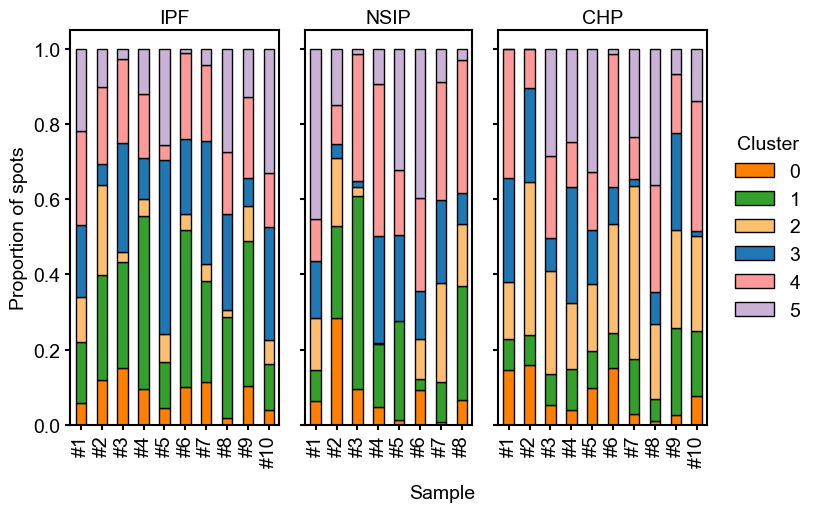

In [14]:
for i in range(6,7):
    mclust = np.unique(adata_vis.obs[f'mclust_refined_{i}'])
    df = adata_vis[(adata_vis.obs['cond']!="UNC") &     (adata_vis.obs[f'mclust_refined_{i}'].isin(mclust))].obs[['library_id','cond','lobe_lr','sex', 'probe_lot', "lobe",'outcome_long','outcome_24m', f'mclust_refined_{i}']]
    # Create a blank dataframe
    counts = df.groupby(['library_id', f'mclust_refined_{i}']).size().reset_index(name='count')
    # Step 2: Compute proportions per library_id
    total_counts = counts.groupby(['library_id'])['count'].transform('sum')
    counts['proportion'] = counts['count'] / total_counts

    # Step 3: Pivot to get factor_assigned proportions per library_id
    pivot_df = counts.pivot_table(
        index='library_id',
        columns=f'mclust_refined_{i}',
        values='proportion',
        fill_value=0
    )
    # Re-order columns
    pivot_df = pivot_df[list(range(i))]
    cond_order = df[['library_id', 'cond']].drop_duplicates().set_index('library_id').sort_index()
    pivot_df['cond'] = cond_order['cond']

    pivot_df['cond']  = pd.Categorical(pivot_df['cond'], categories=["IPF","NSIP",'CHP'], ordered=True)
    pivot_df.sort_values("cond")
    conditions = ["IPF","NSIP","CHP"]

    import matplotlib.gridspec as gridspec

    # Custom width ratios (adjust as needed — one per condition)
    widths = [
        pivot_df[pivot_df['cond'] == conditions[0]].shape[0] * 0.15,
        pivot_df[pivot_df['cond'] == conditions[1]].shape[0] * 0.15,
        pivot_df[pivot_df['cond'] == conditions[2]].shape[0] * 0.15
    ]

    fig = plt.figure(figsize=(sum(widths) * 2, 5))  # overall figure size
    gs = gridspec.GridSpec(1, len(conditions), width_ratios=widths)

    axes = [fig.add_subplot(gs[i]) for i in range(len(conditions))]



    # Step 3: Set up subplots
    #fig, axes = plt.subplots(1, len(conditions), figsize=(3 * len(conditions), 5), sharey=True)

    # Custom color palette
    color_dict = dict(zip(
    range(i+1), colors[:i]


    ))

    # Step 4: Plot each condition
    for ax, cond in zip(axes, conditions):
        # Without lay_id
        #subset = pivot_df[pivot_df['cond'] == cond].drop(columns='cond')
        
        ## With lay_id
        subset = (pivot_df[pivot_df['cond'] == cond]
            .drop(columns='cond')
            .rename(index = key_map) # .rename() updates library_id with lay_id
            .sort_index(
                key=lambda idx: [int(label.split('#')[1]) for label in idx.astype(str)])
                ) # sorts it naturally from 1 to 10
    
        # Strip everything before #
        subset.index = "#" + subset.index.astype(str).str.split("#").str[1]
        ##

        subset.plot(kind='bar', stacked=True, ax=ax,
                    color=color_dict, 
                    edgecolor='black')
        ax.set_title(f'{cond}', fontsize = 14, pad = 5)
        ax.set_xlabel('Sample')
        ax.set_ylabel('Proportion of spots')
        ax.legend(
        title="Cluster",
        loc='center left',
        bbox_to_anchor=(1.05, 0.5),  # pushes legend outside to the right
        frameon=False
    )

    for i in range(2):
        axes[i].get_legend().remove()

    for ax in axes:
        ax.set_xlabel("")

    for ax in axes[1:]:
        ax.tick_params(labelleft=False)
        ax.set_ylabel("")


    fig.text(0.5, -0.02, "Sample", fontsize = 14)

    plt.tight_layout()
    #plt.savefig(os.path.join(save_dir, "stacked_bar_mclust_refined_individual_by_cond.pdf"), bbox_inches = 'tight', transparent = True)
    plt.show()

    # # Extract handles and labels
    # handles, labels = ax.get_legend_handles_labels()

    # # Create separate figure for legend
    # fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
    # fig_legend.legend(handles, labels, title="Niches", loc='right', frameon=False, bbox_to_anchor=(1.1, 0.5), ncol=4)  # ncol=2 for horizontal spread
    # fig_legend.tight_layout()
    # fig_legend.show()

    
    


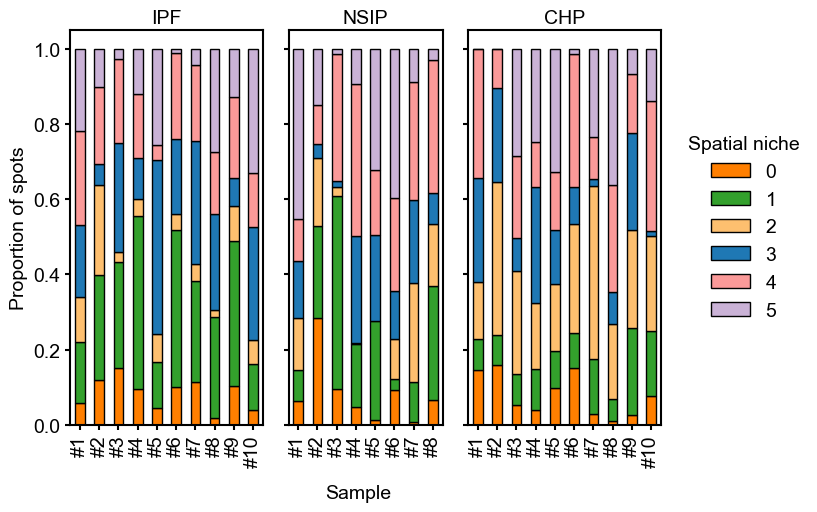

<Figure size 400x200 with 0 Axes>

In [15]:
i = 6
mclust = np.unique(adata_vis.obs[f'mclust_refined_{i}'])
df = adata_vis[(adata_vis.obs['cond']!="UNC") &     (adata_vis.obs[f'mclust_refined_{i}'].isin(mclust))].obs[['library_id','cond','lobe_lr','sex', 'probe_lot', "lobe",'outcome_long','outcome_24m', f'mclust_refined_{i}']]
# Create a blank dataframe
counts = df.groupby(['library_id', f'mclust_refined_{i}']).size().reset_index(name='count')
# Step 2: Compute proportions per library_id
total_counts = counts.groupby(['library_id'])['count'].transform('sum')
counts['proportion'] = counts['count'] / total_counts

# Step 3: Pivot to get factor_assigned proportions per library_id
pivot_df = counts.pivot_table(
    index='library_id',
    columns=f'mclust_refined_{i}',
    values='proportion',
    fill_value=0
)
# Re-order columns
pivot_df = pivot_df[list(range(i))]
cond_order = df[['library_id', 'cond']].drop_duplicates().set_index('library_id').sort_index()
pivot_df['cond'] = cond_order['cond']

pivot_df['cond']  = pd.Categorical(pivot_df['cond'], categories=["IPF","NSIP",'CHP'], ordered=True)
pivot_df.sort_values("cond")
conditions = ["IPF","NSIP","CHP"]

import matplotlib.gridspec as gridspec

# Custom width ratios (adjust as needed — one per condition)
widths = [
    pivot_df[pivot_df['cond'] == conditions[0]].shape[0] * 0.15,
    pivot_df[pivot_df['cond'] == conditions[1]].shape[0] * 0.15,
    pivot_df[pivot_df['cond'] == conditions[2]].shape[0] * 0.15
]

fig = plt.figure(figsize=(sum(widths) * 2, 5))  # overall figure size
gs = gridspec.GridSpec(1, len(conditions), width_ratios=widths)

axes = [fig.add_subplot(gs[i]) for i in range(len(conditions))]



# Step 3: Set up subplots
#fig, axes = plt.subplots(1, len(conditions), figsize=(3 * len(conditions), 5), sharey=True)

# Custom color palette
color_dict = dict(zip(
range(i+1), colors[:i]


))

# Step 4: Plot each condition
for ax, cond in zip(axes, conditions):
    # Without lay_id
    #subset = pivot_df[pivot_df['cond'] == cond].drop(columns='cond')

    ## With lay_id
    subset = (pivot_df[pivot_df['cond'] == cond]
        .drop(columns='cond')
        .rename(index = key_map) # .rename() updates library_id with lay_id
        .sort_index(
            key=lambda idx: [int(label.split('#')[1]) for label in idx.astype(str)])
            ) # sorts it naturally from 1 to 10

    # Strip everything before #
    subset.index = "#" + subset.index.astype(str).str.split("#").str[1]
    ##
    subset.plot(kind='bar', stacked=True, ax=ax,
                color=color_dict, 
                edgecolor='black')
    ax.set_title(f'{cond}', fontsize = 14, pad = 5)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Proportion of spots')
    ax.legend(
    title="Spatial niche",
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),  # pushes legend outside to the right
    frameon=False
)

for i in range(2):
    axes[i].get_legend().remove()

for ax in axes:
    ax.set_xlabel("")

for ax in axes[1:]:
    ax.tick_params(labelleft=False)
    ax.set_ylabel("")


fig.text(0.4, -0.02, "Sample", fontsize = 14)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "stacked_bar_mclust_refined_6_individual_by_cond.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()

# Extract handles and labels
handles, labels = ax.get_legend_handles_labels()

# Create separate figure for legend
fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
fig_legend.legend(handles, labels, title="Spatial niche", loc='right', frameon=False, bbox_to_anchor=(1.1, 0.5), ncol=len(labels))  # ncol=2 for horizontal spread

fig_legend.tight_layout()
fig_legend.savefig(os.path.join(save_dir, "stacked_bar_mclust_refined_6_individual_by_cond_legend.pdf"), bbox_inches = 'tight', transparent = True)
fig_legend.show()





In [16]:
os.makedirs('csv', exist_ok=True)

In [17]:
# Save spatial niche proportions

for i in range(4,20):
    mclust = np.unique(adata_vis.obs[f'mclust_refined_{i}'])
    df = adata_vis[(adata_vis.obs['cond']!="UNC") &    
                    (adata_vis.obs[f'mclust_refined_{i}'].isin(mclust))].obs[['library_id','cond','lobe_lr','sex', 'probe_lot', "lobe",'outcome_long','outcome_24m', f'mclust_refined_{i}']]
    counts = df.groupby(['library_id', f'mclust_refined_{i}']).size().reset_index(name='count')
    # Step 2: Compute proportions per library_id
    total_counts = counts.groupby(['library_id'])['count'].transform('sum')
    counts['proportion'] = counts['count'] / total_counts

    # Step 3: Pivot to get factor_assigned proportions per library_id
    pivot_df = counts.pivot_table(
        index='library_id',
        columns=f'mclust_refined_{i}',
        values='proportion',
        fill_value=0
    )   
    pivot_df.to_csv(f"csv/prop_no_unc_mclust_refined_{i}.csv")


In [18]:
counts

,library_id,mclust_refined_19,count,proportion
0,06_30914_A1,0,44,0.009763
1,06_30914_A1,1,0,0.000000
2,06_30914_A1,2,0,0.000000
3,06_30914_A1,3,54,0.011981
4,06_30914_A1,4,0,0.000000
...,...,...,...,...
527,24_27523_C5,14,0,0.000000
528,24_27523_C5,15,911,0.223449
529,24_27523_C5,16,71,0.017415
530,24_27523_C5,17,0,0.000000


In [19]:
for i in range(4,20):
    mclust = np.unique(adata_vis.obs[f'mclust_refined_{i}'])
    df = adata_vis[(adata_vis.obs['cond']=="UNC") &    
                    (adata_vis.obs[f'mclust_refined_{i}'].isin(mclust))].obs[['library_id','cond','lobe_lr','sex', 'probe_lot', "lobe",'outcome_long','outcome_24m', f'mclust_refined_{i}']]
    counts = df.groupby(['library_id', f'mclust_refined_{i}']).size().reset_index(name='count')
    # Step 2: Compute proportions per library_id
    total_counts = counts.groupby(['library_id'])['count'].transform('sum')
    counts['proportion'] = counts['count'] / total_counts

    # Step 3: Pivot to get factor_assigned proportions per library_id
    pivot_df = counts.pivot_table(
        index='library_id',
        columns=f'mclust_refined_{i}',
        values='proportion',
        fill_value=0
    )   
    pivot_df.to_csv(f"csv/unc_prop_mclust_refined_{i}.csv")